In [1]:
import numpy as np
import znnl as nl

import pandas as pd

from flax import linen as nn
import optax

import matplotlib.pyplot as plt
from neural_tangents import stax

import h5py as hf
from scipy.stats import pearsonr

from rich.progress import track

import seaborn as sns

Using backend: cpu

Available hardware:

TFRT_CPU_0

In [2]:
generator = nl.data.MNISTGenerator(ds_size=20)

In [3]:
dense_network = stax.serial(
        stax.Flatten(),
        stax.Dense(128, b_std=0.01, parameterization="standard"),
        stax.Relu(),
        stax.Dense(128, b_std=0.01, parameterization="standard"),
        stax.Relu(),
        stax.Dense(10, b_std=0.01, parameterization="standard"),
    )

dense_model = nl.models.NTModel(
            nt_module=dense_network,
            optimizer=optax.sgd(0.2),
            input_shape=(1, 28, 28, 1),
    )

# dense_training_strategy = nl.training_strategies.SimpleTraining(
#         model=dense_model, 
#         loss_fn=nl.loss_functions.MeanPowerLoss(order=2),
#         accuracy_fn=nl.accuracy_functions.LabelAccuracy(),
# #         recorders=[train_recorder, test_recorder],
#     )

# _ = dense_training_strategy.train_model(
#             train_ds=generator.train_ds,
#             test_ds=generator.test_ds, 
#             epochs=2, 
#             batch_size=50,
#         )

In [5]:
conv_network = stax.serial(
      stax.Conv(32, filter_shape=(2, 2), b_std=0.01, parameterization="standard"),
      stax.Relu(),
      stax.AvgPool(window_shape=(2, 2), strides=(2, 2)),
      stax.Conv(64, filter_shape=(2, 2), b_std=0.01, parameterization="standard"),
      stax.Relu(),
      stax.AvgPool(window_shape=(2, 2)),
      stax.Flatten(),
      stax.Dense(128, b_std=0.01, parameterization="standard"),
      stax.Relu(),
      stax.Dense(10, b_std=0.01, parameterization="standard")
    )
conv_model = nl.models.NTModel(
            nt_module=conv_network,
            optimizer=optax.sgd(0.2),
            input_shape=(1, 28, 28, 1),
    )

# conv_training_strategy = nl.training_strategies.SimpleTraining(
#         model=conv_model, 
#         loss_fn=nl.loss_functions.MeanPowerLoss(order=2),
#         accuracy_fn=nl.accuracy_functions.LabelAccuracy(),
# #         recorders=[train_recorder, test_recorder],
#     )

# _ = conv_training_strategy.train_model(
#             train_ds=generator.train_ds,
#             test_ds=generator.test_ds, 
#             epochs=100, 
#             batch_size=50,
#         )

In [6]:
dense_ntk = dense_model.compute_ntk(generator.train_ds["inputs"])["empirical"]

In [7]:
conv_ntk = conv_model.compute_ntk(generator.train_ds["inputs"])["empirical"]

In [8]:
dense_eigs, _ = np.linalg.eigh(dense_ntk)
conv_eigs, _ = np.linalg.eigh(conv_ntk)

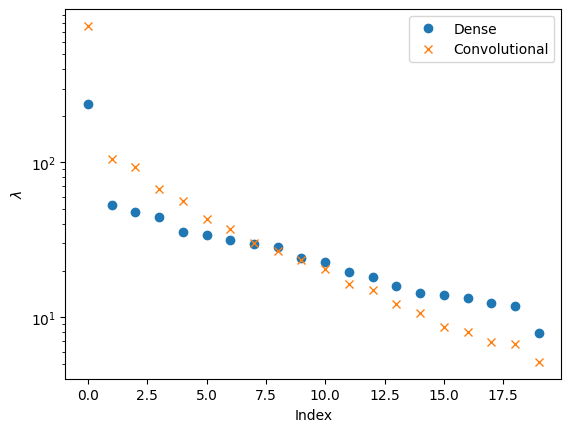

In [9]:
# fig, ax = 

plt.plot(dense_eigs[::-1], 'o', label="Dense")
plt.plot(conv_eigs[::-1], 'x', label="Convolutional")
plt.yscale("log")
plt.legend()
plt.ylabel(r"$\lambda$")
plt.xlabel("Index")
plt.savefig("spectrum.pdf")
plt.show()